Marginal effect difference p-values:
{'in_degree': 'p = 0.847', 'out_degree': 'p = 0.617', 'closeness': 'p = 0.926', 'eigenvector': 'p = 0.499'}


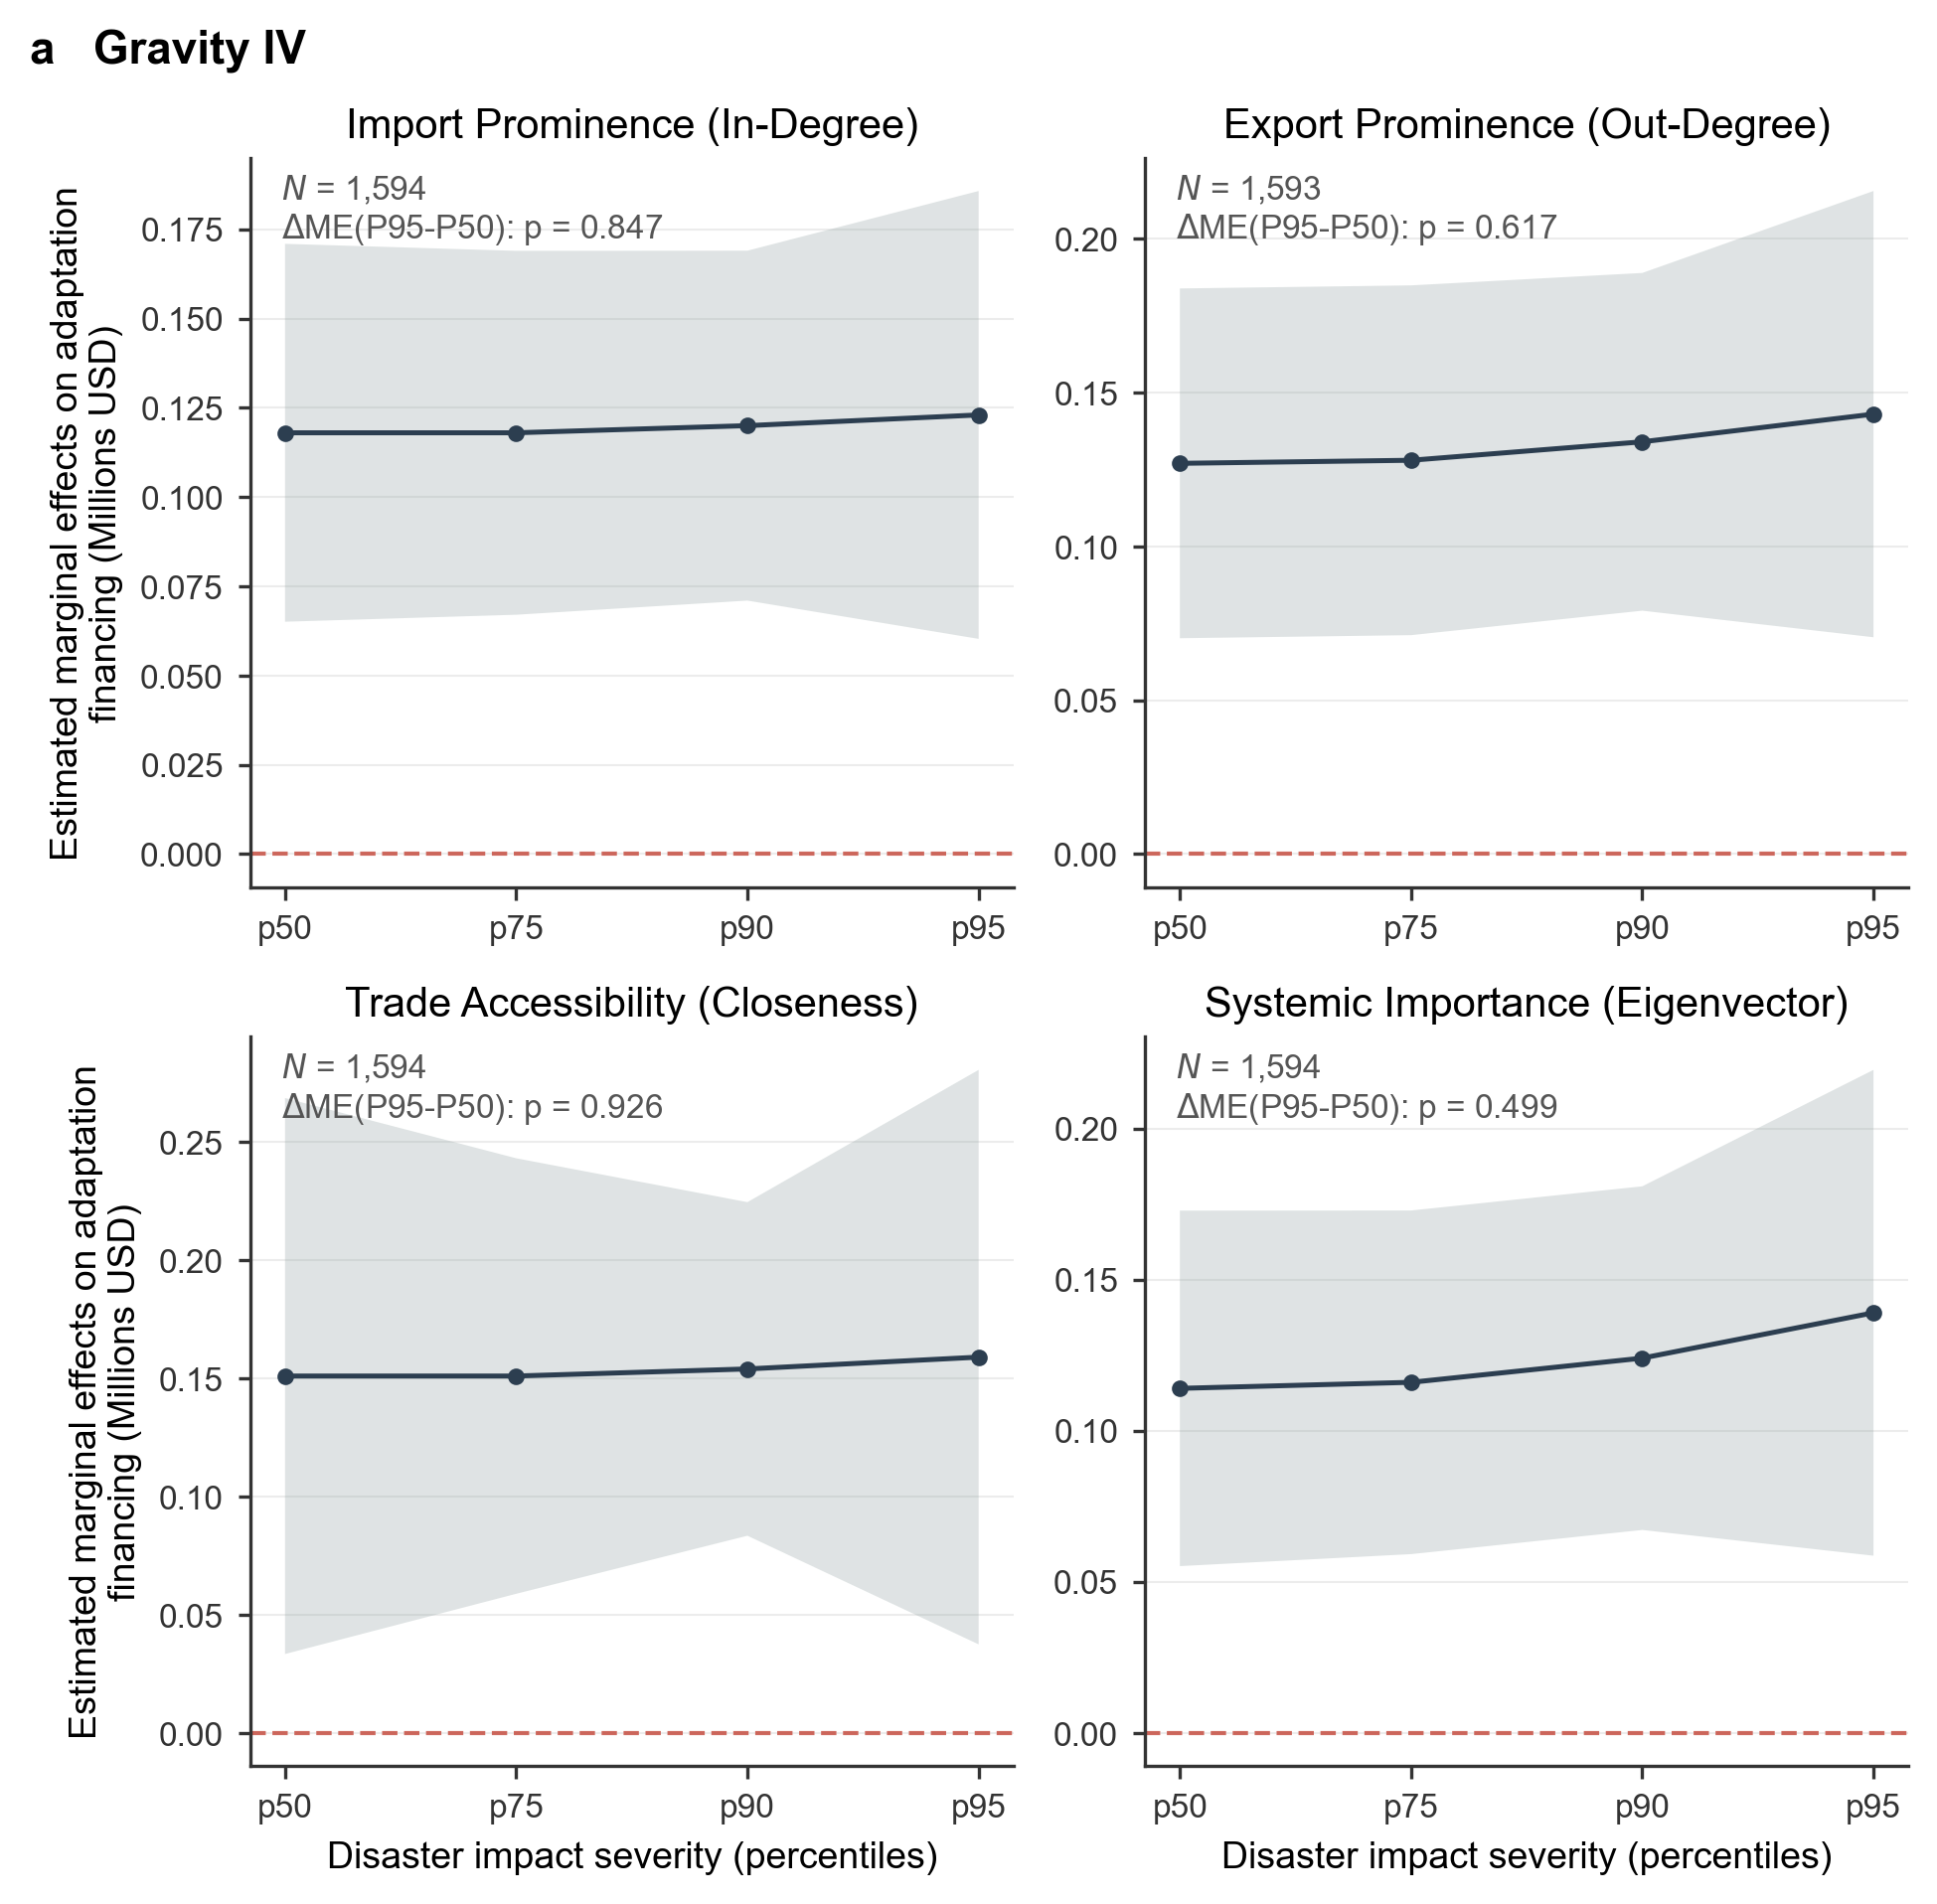

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import math

# ----------------- 全局设置: Nature 风格 -----------------
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['axes.linewidth'] = 0.8

# ----------------- 基本设置 -----------------
centralities = ['in_degree', 'out_degree', 'closeness', 'eigenvector']

legend_names = {
    'in_degree': 'Import Prominence (In-Degree)',
    'out_degree': 'Export Prominence (Out-Degree)',
    'closeness': 'Trade Accessibility (Closeness)',
    'eigenvector': 'Systemic Importance (Eigenvector)'
}

col_mapping = {
    'in_degree': 1,
    'out_degree': 2,
    'closeness': 3,
    'eigenvector': 4
}

labels = ['P50', 'P75', 'P90', 'P95']
x_values = np.arange(len(labels))

# ----------------- 文件路径 -----------------
margins_csv = "../Moderation_disaster_Table2_Marginal_Effects_CF.csv"
mediff_csv = "../Moderation_disaster_Table3_Marginal_Effects_Differences_CF.csv"

# ----------------- 清理函数 -----------------
def clean_cell(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    x = re.sub(r'^="|"$', '', x)
    x = x.replace('="', '').replace('"', '').strip()
    return x

def parse_number(x):
    x = clean_cell(x)
    x = x.replace('*', '')
    x = x.replace('(', '').replace(')', '')
    x = x.replace(',', '')
    x = x.replace('=', '')
    x = x.replace('"', '')
    x = x.strip()

    if x in ["", "nan", "NaN", "."]:
        return np.nan

    return float(x)

def p_from_coef_se(coef, se):
    if pd.isna(coef) or pd.isna(se) or se == 0:
        return np.nan

    z = abs(coef / se)
    p = math.erfc(z / math.sqrt(2))  # two-sided normal p-value
    return p

def format_p(p):
    if pd.isna(p):
        return "p = NA"
    elif p < 0.001:
        return "p < 0.001"
    else:
        return f"p = {p:.3f}"

# =========================================================
# 自动从 Table 3 提取边际效应差异 p 值
# =========================================================

diff_row_keywords = {
    "p75_p50": "ME(P75) - ME(P50)",
    "p90_p50": "ME(P90) - ME(P50)",
    "p95_p50": "ME(P95) - ME(P50)",
}

def extract_mediff_p_values(mediff_csv, target_diff="p95_p50"):
    """
    从 Table 3 中提取某一个 marginal effect difference 的 p 值。
    
    target_diff 可选：
        p75_p50, p90_p50, p95_p50, p99_p50
    """

    df_diff = pd.read_csv(mediff_csv, header=None, skiprows=1, dtype=str)
    df_diff = df_diff.map(clean_cell)
    df_diff.columns = range(df_diff.shape[1])

    keyword = diff_row_keywords[target_diff]

    row_mask = df_diff.iloc[:, 0].astype(str).str.contains(
        keyword,
        case=False,
        na=False,
        regex=False
    )

    if not row_mask.any():
        raise ValueError(f"Cannot find row in Table 3: {keyword}")

    row_idx = df_diff.index[row_mask][0]

    p_dict = {}

    for var in centralities:
        col_idx = col_mapping[var]

        coef = parse_number(df_diff.iloc[row_idx, col_idx])
        se = parse_number(df_diff.iloc[row_idx + 1, col_idx])

        p = p_from_coef_se(coef, se)
        p_dict[var] = format_p(p)

    return p_dict

# 选择要标记的边际效应差异
# 可改为 "p75_p50", "p90_p50", "p95_p50", "p99_p50"
target_diff = "p95_p50"

mediff_p_values = extract_mediff_p_values(
    mediff_csv,
    target_diff=target_diff
)

print("Marginal effect difference p-values:")
print(mediff_p_values)

# ----------------- 读取 Table 2: Marginal Effects -----------------
df_raw = pd.read_csv(margins_csv, header=None, skiprows=1, dtype=str)

df_raw = df_raw.map(clean_cell)
df_raw.columns = range(df_raw.shape[1])

# ----------------- 画图 -----------------
fig, axes = plt.subplots(2, 2, figsize=(6.5, 6.2), dpi=300)
axes = axes.flatten()

for i, var in enumerate(centralities):
    ax = axes[i]
    col_idx = col_mapping[var]

    margins = []
    ses = []

    # 提取 ME at P50-P99
    for label in labels:
        row_mask = df_raw.iloc[:, 0].astype(str).str.contains(
            f"ME at {label}",
            case=False,
            na=False,
            regex=False
        )

        if not row_mask.any():
            raise ValueError(f"Cannot find row: ME at {label}")

        row_idx = df_raw.index[row_mask][0]

        coef = parse_number(df_raw.iloc[row_idx, col_idx])
        se = parse_number(df_raw.iloc[row_idx + 1, col_idx])

        margins.append(coef)
        ses.append(se)

    margins = np.array(margins, dtype=float)
    ses = np.array(ses, dtype=float)

    ci_lb = margins - 1.96 * ses
    ci_ub = margins + 1.96 * ses

    # 提取 Observations
    obs_mask = df_raw.iloc[:, 0].astype(str).str.contains(
        "Observation",
        case=False,
        na=False,
        regex=False
    )

    if obs_mask.any():
        obs_idx = df_raw.index[obs_mask][0]
        obs_val = parse_number(df_raw.iloc[obs_idx, col_idx])

        if pd.isna(obs_val):
            obs_formatted = "NA"
        else:
            obs_formatted = f"{int(obs_val):,}"
    else:
        obs_formatted = "NA"

    # 置信区间阴影
    ax.fill_between(
        x_values,
        ci_lb,
        ci_ub,
        color='#95A5A6',
        alpha=0.30,
        edgecolor='none'
    )

    # 主线
    ax.plot(
        x_values,
        margins,
        marker='o',
        linestyle='-',
        color='#2C3E50',
        linewidth=1.2,
        markersize=3,
        markeredgewidth=1.0
    )

    # 零值基准线
    ax.axhline(
        0,
        color='#C0392B',
        linestyle='--',
        linewidth=1,
        alpha=0.75
    )

    # 左上角注释：改为 Table 3 的 marginal effects difference p 值
    sig_text = mediff_p_values.get(var, 'p = NA')

    text_str = (
        f"$\\mathit{{N}}$ = {obs_formatted}\n"
        f"$\\Delta$ME(P95-P50): {sig_text}"
    )

    ax.text(
        0.04,
        0.98,
        text_str,
        transform=ax.transAxes,
        fontsize=8,
        color='#555555',
        verticalalignment='top',
        horizontalalignment='left'
    )

    # 标题和坐标轴
    ax.set_title(legend_names[var], pad=5)
    ax.set_xticks(x_values)
    ax.set_xticklabels([l.lower() for l in labels])

    # 极简边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

    ax.tick_params(
        colors='#333333',
        direction='out',
        length=3,
        width=0.8
    )

    ax.set_axisbelow(True)
    ax.grid(
        axis='y',
        linestyle='-',
        color='#E0E0E0',
        alpha=0.6,
        linewidth=0.5
    )

    if i % 2 == 0:
        ax.set_ylabel(
            'Estimated marginal effects on adaptation\nfinancing (Millions USD)',
            fontsize=9
        )

    if i >= 2:
        ax.set_xlabel(
            'Disaster impact severity (percentiles)',
            fontsize=9
        )

plt.tight_layout()

fig.text(
    0.01,
    1.02,
    'a   Gravity IV',
    fontsize=11,
    fontweight='bold',
    va='top',
    ha='left'
)

plt.savefig(
    'Final/Fig.6_marginal_effects_disaster.pdf',
    bbox_inches='tight',
    transparent=True
)

plt.savefig(
    'Final/Fig.6_marginal_effects_disaster.png',
    dpi=1200,
    bbox_inches='tight',
    transparent=False
)

plt.show()

Marginal effect difference p-values:
{'in_degree': 'p = 0.106', 'out_degree': 'p = 0.113', 'closeness': 'p = 0.169', 'eigenvector': 'p = 0.079'}


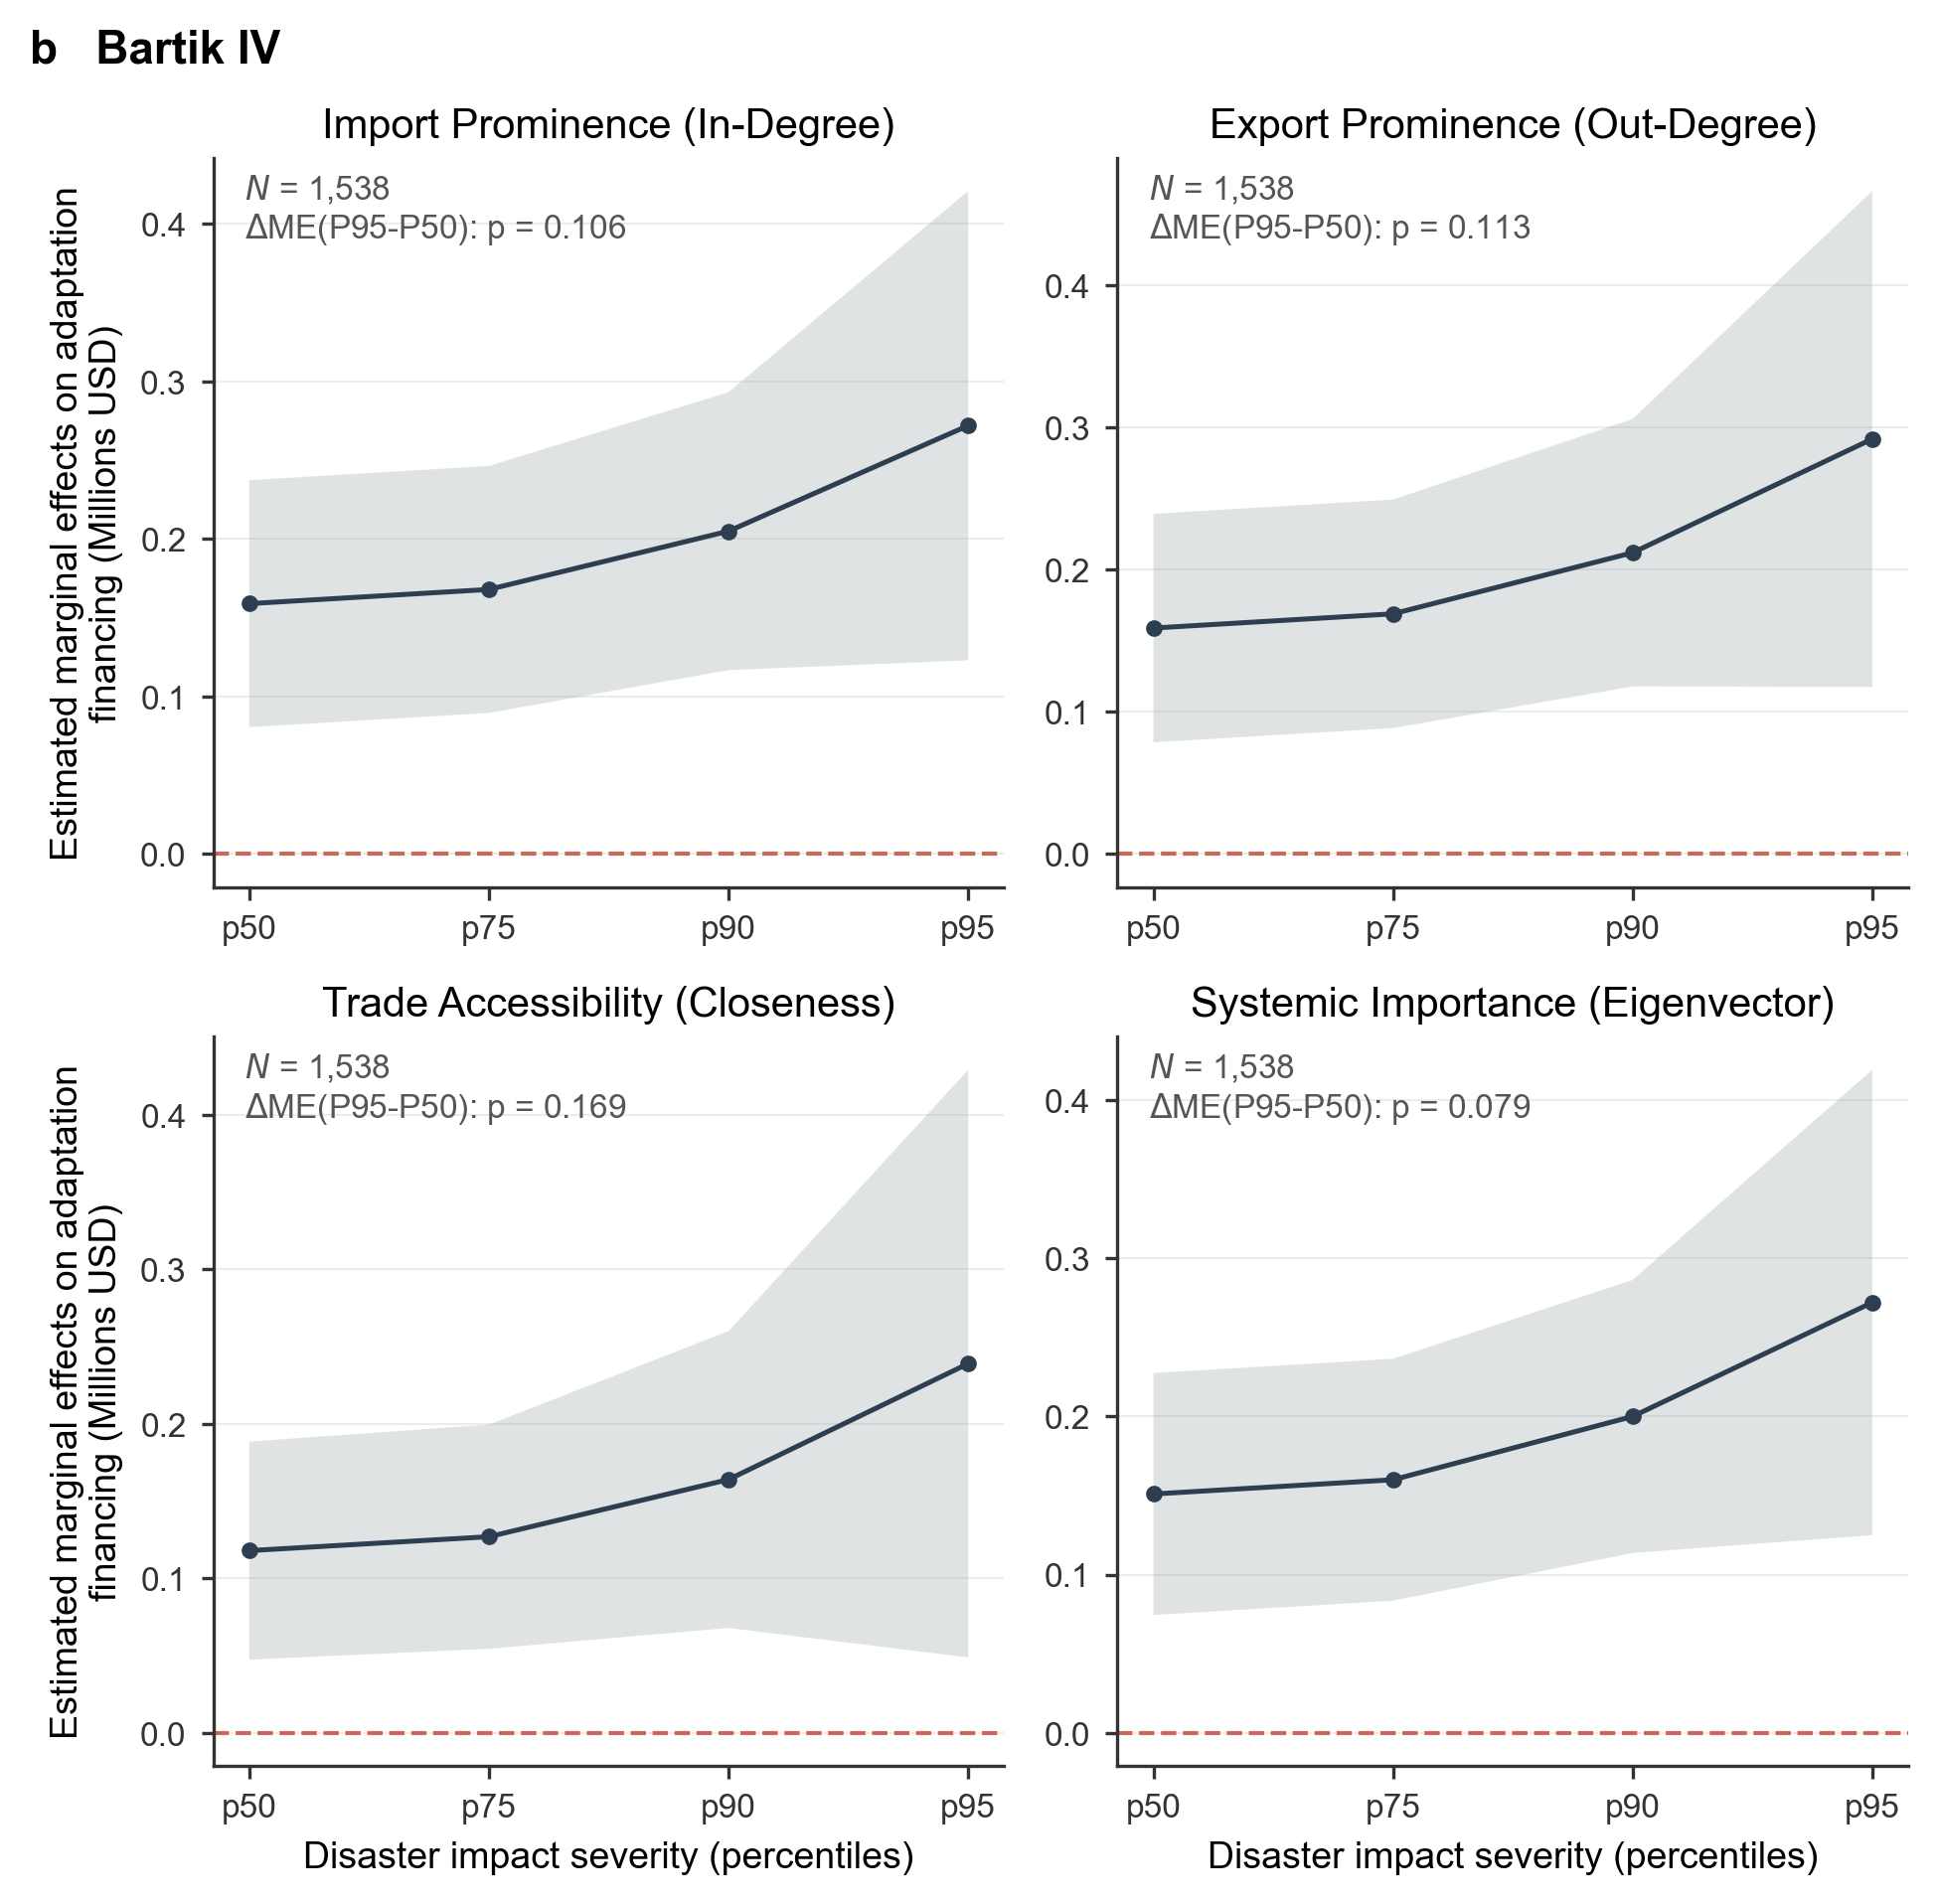

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import math

# ----------------- 全局设置: Nature 风格 -----------------
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['axes.linewidth'] = 0.8

# ----------------- 基本设置 -----------------
centralities = ['in_degree', 'out_degree', 'closeness', 'eigenvector']

legend_names = {
    'in_degree': 'Import Prominence (In-Degree)',
    'out_degree': 'Export Prominence (Out-Degree)',
    'closeness': 'Trade Accessibility (Closeness)',
    'eigenvector': 'Systemic Importance (Eigenvector)'
}

col_mapping = {
    'in_degree': 1,
    'out_degree': 2,
    'closeness': 3,
    'eigenvector': 4
}

labels = ['P50', 'P75', 'P90', 'P95']
x_values = np.arange(len(labels))

# ----------------- 文件路径 -----------------
margins_csv = "../Moderation_disaster_Table2_Marginal_Effects_CF_Bartik.csv"
mediff_csv = "../Moderation_disaster_Table3_Marginal_Effects_Differences_CF_Bartik.csv"

# ----------------- 清理函数 -----------------
def clean_cell(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    x = re.sub(r'^="|"$', '', x)
    x = x.replace('="', '').replace('"', '').strip()
    return x

def parse_number(x):
    x = clean_cell(x)
    x = x.replace('*', '')
    x = x.replace('(', '').replace(')', '')
    x = x.replace(',', '')
    x = x.replace('=', '')
    x = x.replace('"', '')
    x = x.strip()

    if x in ["", "nan", "NaN", "."]:
        return np.nan

    return float(x)

def p_from_coef_se(coef, se):
    if pd.isna(coef) or pd.isna(se) or se == 0:
        return np.nan

    z = abs(coef / se)
    p = math.erfc(z / math.sqrt(2))  # two-sided normal p-value
    return p

def format_p(p):
    if pd.isna(p):
        return "p = NA"
    elif p < 0.001:
        return "p < 0.001"
    else:
        return f"p = {p:.3f}"

# =========================================================
# 自动从 Table 3 提取边际效应差异 p 值
# =========================================================

diff_row_keywords = {
    "p75_p50": "ME(P75) - ME(P50)",
    "p90_p50": "ME(P90) - ME(P50)",
    "p95_p50": "ME(P95) - ME(P50)",
}

def extract_mediff_p_values(mediff_csv, target_diff="p95_p50"):
    """
    从 Table 3 中提取某一个 marginal effect difference 的 p 值。
    
    target_diff 可选：
        p75_p50, p90_p50, p95_p50, p99_p50
    """

    df_diff = pd.read_csv(mediff_csv, header=None, skiprows=1, dtype=str)
    df_diff = df_diff.map(clean_cell)
    df_diff.columns = range(df_diff.shape[1])

    keyword = diff_row_keywords[target_diff]

    row_mask = df_diff.iloc[:, 0].astype(str).str.contains(
        keyword,
        case=False,
        na=False,
        regex=False
    )

    if not row_mask.any():
        raise ValueError(f"Cannot find row in Table 3: {keyword}")

    row_idx = df_diff.index[row_mask][0]

    p_dict = {}

    for var in centralities:
        col_idx = col_mapping[var]

        coef = parse_number(df_diff.iloc[row_idx, col_idx])
        se = parse_number(df_diff.iloc[row_idx + 1, col_idx])

        p = p_from_coef_se(coef, se)
        p_dict[var] = format_p(p)

    return p_dict

# 选择要标记的边际效应差异
# 可改为 "p75_p50", "p90_p50", "p95_p50", "p99_p50"
target_diff = "p95_p50"

mediff_p_values = extract_mediff_p_values(
    mediff_csv,
    target_diff=target_diff
)

print("Marginal effect difference p-values:")
print(mediff_p_values)

# ----------------- 读取 Table 2: Marginal Effects -----------------
df_raw = pd.read_csv(margins_csv, header=None, skiprows=1, dtype=str)

df_raw = df_raw.map(clean_cell)
df_raw.columns = range(df_raw.shape[1])

# ----------------- 画图 -----------------
fig, axes = plt.subplots(2, 2, figsize=(6.5, 6.2), dpi=300)
axes = axes.flatten()

for i, var in enumerate(centralities):
    ax = axes[i]
    col_idx = col_mapping[var]

    margins = []
    ses = []

    # 提取 ME at P50-P99
    for label in labels:
        row_mask = df_raw.iloc[:, 0].astype(str).str.contains(
            f"ME at {label}",
            case=False,
            na=False,
            regex=False
        )

        if not row_mask.any():
            raise ValueError(f"Cannot find row: ME at {label}")

        row_idx = df_raw.index[row_mask][0]

        coef = parse_number(df_raw.iloc[row_idx, col_idx])
        se = parse_number(df_raw.iloc[row_idx + 1, col_idx])

        margins.append(coef)
        ses.append(se)

    margins = np.array(margins, dtype=float)
    ses = np.array(ses, dtype=float)

    ci_lb = margins - 1.96 * ses
    ci_ub = margins + 1.96 * ses

    # 提取 Observations
    obs_mask = df_raw.iloc[:, 0].astype(str).str.contains(
        "Observation",
        case=False,
        na=False,
        regex=False
    )

    if obs_mask.any():
        obs_idx = df_raw.index[obs_mask][0]
        obs_val = parse_number(df_raw.iloc[obs_idx, col_idx])

        if pd.isna(obs_val):
            obs_formatted = "NA"
        else:
            obs_formatted = f"{int(obs_val):,}"
    else:
        obs_formatted = "NA"

    # 置信区间阴影
    ax.fill_between(
        x_values,
        ci_lb,
        ci_ub,
        color='#95A5A6',
        alpha=0.30,
        edgecolor='none'
    )

    # 主线
    ax.plot(
        x_values,
        margins,
        marker='o',
        linestyle='-',
        color='#2C3E50',
        linewidth=1.2,
        markersize=3,
        markeredgewidth=1.0
    )

    # 零值基准线
    ax.axhline(
        0,
        color='#C0392B',
        linestyle='--',
        linewidth=1,
        alpha=0.75
    )

    # 左上角注释：改为 Table 3 的 marginal effects difference p 值
    sig_text = mediff_p_values.get(var, 'p = NA')

    text_str = (
        f"$\\mathit{{N}}$ = {obs_formatted}\n"
        f"$\\Delta$ME(P95-P50): {sig_text}"
    )

    ax.text(
        0.04,
        0.98,
        text_str,
        transform=ax.transAxes,
        fontsize=8,
        color='#555555',
        verticalalignment='top',
        horizontalalignment='left'
    )

    # 标题和坐标轴
    ax.set_title(legend_names[var], pad=5)
    ax.set_xticks(x_values)
    ax.set_xticklabels([l.lower() for l in labels])

    # 极简边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

    ax.tick_params(
        colors='#333333',
        direction='out',
        length=3,
        width=0.8
    )

    ax.set_axisbelow(True)
    ax.grid(
        axis='y',
        linestyle='-',
        color='#E0E0E0',
        alpha=0.6,
        linewidth=0.5
    )

    if i % 2 == 0:
        ax.set_ylabel(
            'Estimated marginal effects on adaptation\nfinancing (Millions USD)',
            fontsize=9
        )

    if i >= 2:
        ax.set_xlabel(
            'Disaster impact severity (percentiles)',
            fontsize=9
        )

plt.tight_layout()

fig.text(
    0.01,
    1.02,
    'b   Bartik IV',
    fontsize=11,
    fontweight='bold',
    va='top',
    ha='left'
)

plt.savefig(
    'Final/Fig.6_marginal_effects_disaster_Bartik.pdf',
    bbox_inches='tight',
    transparent=True
)

plt.savefig(
    'Final/Fig.6_marginal_effects_disaster_Bartik.png',
    dpi=1200,
    bbox_inches='tight',
    transparent=False
)

plt.show()